In [1]:
import pandas as pd
import sqlite3

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [10]:
pageviews_query = """
SELECT 
    DATE(datetime) as date,
    COUNT(*) as views
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY DATE(datetime)
ORDER BY date
"""
pageviews_df = pd.read_sql_query(pageviews_query, connection, parse_dates=['date'])
pageviews_df.head()

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1


In [4]:
commits_query = """
SELECT 
    DATE(timestamp) as date,
    COUNT(*) as commits
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY DATE(timestamp)
ORDER BY date
"""
commits_df = pd.read_sql_query(commits_query, connection, parse_dates=['date'])

In [9]:
df = pd.merge(pageviews_df, commits_df, on='date', how='inner')
df = df.sort_values('date')
df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


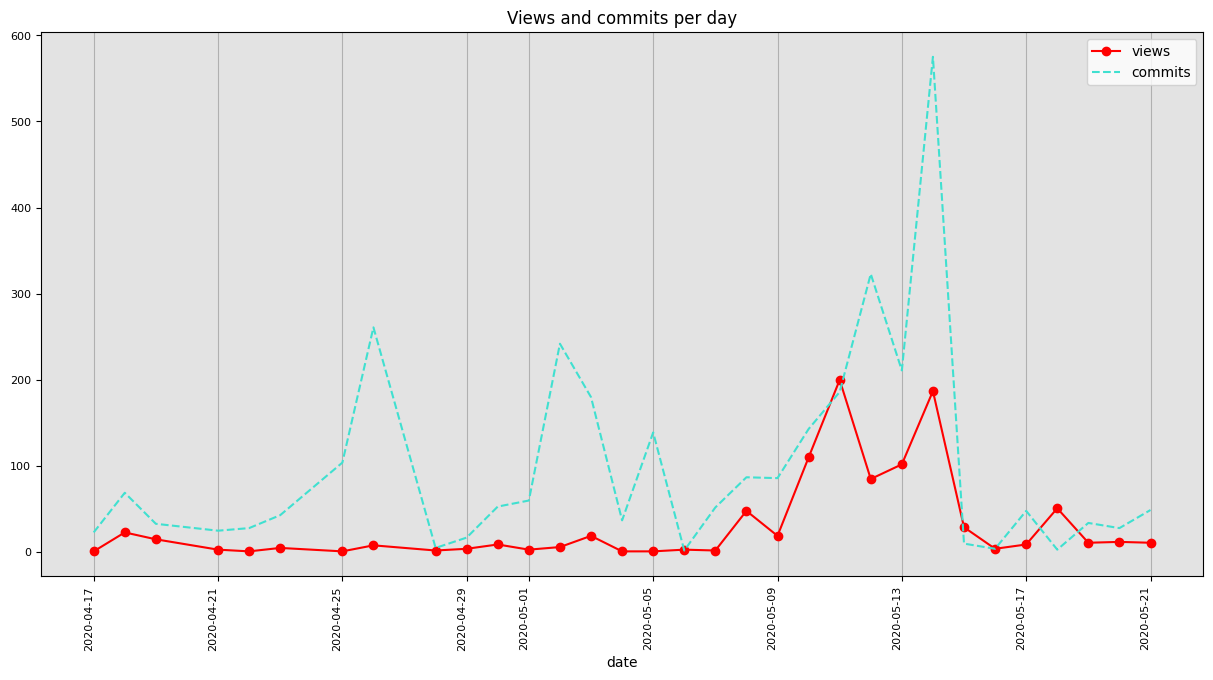

In [6]:
ax = df.plot(x='date', y='views', color='red', figsize=(15,8), fontsize=8, style='o-')
df.plot(x='date', y='commits', label='commits', color='turquoise', ax=ax, linestyle='--')

ax.set_title('Views and commits per day')
ax.set_xlabel('date')
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='x')
ax.set_facecolor('#E3E3E3')

In [7]:
df[df['views'] > 150]

,date,views,commits
21,2020-05-11,200,186
24,2020-05-14,187,575


«Сколько раз количество просмотров превышало 150?» «Ответ — 2.»